<div style='text-align: center;'>
<img src="images/math60082-banner.png" alt="image" width="80%" height="auto">
</div>

# Lab Workbook - Week 8


# Tasks


1. Use point estimates of the value function $V$ to derive approximations of $\frac{\partial V}{\partial S}$ and  $\frac{\partial^2 V}{\partial S^2}$.


## How does this help us?


2. Trying sketching out the grid.


3. Consider a small example with $imax=jmax=4$, setup storage arrays for the grid and plot out the value of the option at expiry and the boundary conditions.


In [1]:
# To get started import some libraries
import numpy
import matplotlib.pyplot as plt

In [4]:
# setup the parameters
sigma = 0.4
r = 0.05
X = 2
T = 1
iMax = 4
jMax = 4

In [6]:
## calculate the step size and then setup storage for the value
Smax = 4.0
dS = Smax / jMax
dt = T / iMax

S = numpy.linspace(0.0,Smax,jMax+1)
t = numpy.linspace(0.0,T,iMax+1)
vNew = numpy.maximum(S-X,0)
vOld = numpy.maximum(S-X,0)

# calculate the values of S_j and t^i and check they work as expected
for j in range(jMax+1):
    print(S[j],vNew[j])

0.0 0.0
1.0 0.0
2.0 0.0
3.0 1.0
4.0 2.0


## Finite Difference Approximations on the Boundary Conditions


4. Code up the finite difference method and print out the values on screen.


0.3758999999999999


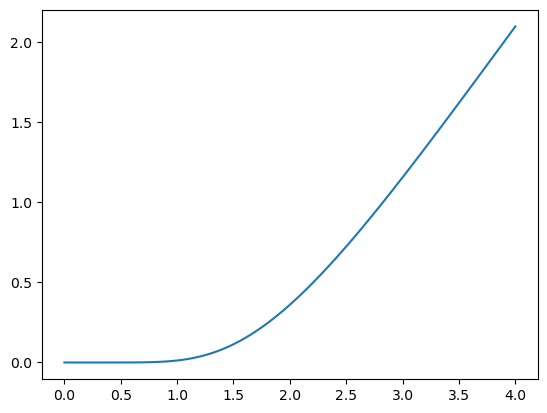

In [19]:
iMax = 1600
jMax = 80

## calculate the step size and then setup storage for the value
Smax = 4.0
dS = Smax / jMax
dt = T / iMax

S = numpy.linspace(0.0,Smax,jMax+1)
t = numpy.linspace(0.0,T,iMax+1)
vNew = numpy.maximum(S-X,0)
vOld = numpy.maximum(S-X,0)

# calculate the values of S_j and t^i and check they work as expected
#for j in range(jMax+1):
#    print(S[j],vNew[j])

for i in range(iMax-1,-1,-1):
    # set V at S=0
    vNew[0] = 0.0
    for j in range(1,jMax):
        A = 0.5*(sigma*sigma*j*j + r*j)*dt 
        B = 1 - sigma*sigma*j*j*dt
        C = 0.5*(sigma*sigma*j*j - r*j)*dt 
        vNew[j] = ( A*vOld[j+1] + B*vOld[j] + C*vOld[j-1]) / (1+r*dt)
    vNew[jMax] = S[jMax] - X*numpy.exp(-r*(T-t[i]))
    
    vOld = numpy.copy(vNew)
    #for j in range(jMax+1):
    #    print(S[j],vNew[j])
print(B)
plt.plot(S,vNew)

5. Try different values of `imax` and `jmax` -- what do you notice?


6. Put your algorithm in a function, and return the solution:
    - Parameters: `sigma`, `r`, `X`, `T`, `imax`, `jmax`
    - return: `vNew`, `S`


In [20]:
def blackScholesExplicit(X,T,r,sigma,iMax,jMax,Smax):
    dt = T / iMax

    S = numpy.linspace(0.0,Smax,jMax+1)
    t = numpy.linspace(0.0,T,iMax+1)
    vNew = numpy.maximum(S-X,0)
    vOld = numpy.maximum(S-X,0)

    for i in range(iMax-1,-1,-1):
        # set V at S=0
        vNew[0] = 0.0
        for j in range(1,jMax):
            A = 0.5*(sigma*sigma*j*j + r*j)*dt 
            B = 1 - sigma*sigma*j*j*dt
            C = 0.5*(sigma*sigma*j*j - r*j)*dt 
            vNew[j] = ( A*vOld[j+1] + B*vOld[j] + C*vOld[j-1]) / (1+r*dt)
        vNew[jMax] = S[jMax] - X*numpy.exp(-r*(T-t[i]))
        
        vOld = numpy.copy(vNew)
        
    return S,vNew

7. Try plotting the solution $V(S,t=0)$ against $S$ for different values of $imax$ and $jmax$


In [21]:
S,V = blackScholesExplicit(X,T,r,sigma,1600,80,4)

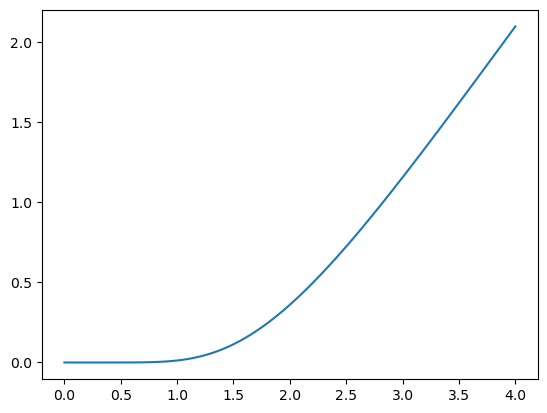

In [22]:
plt.plot(S,V)

In [7]:
# first enter the value of the option at expiry
for j in range(jmax+1):
    vOld[j] = # FILL IN
    vNew[j] = # FILL IN
    print("t=",t[imax],"S=",S[j],"V(S,t)=",vNew[j])

SyntaxError: invalid syntax (1084573181.py, line 3)

In [8]:
# next loop back through time
for i in range(imax-1,-1,-1):
    # apply boundary condition at S=0
    vNew[0] = # FILL IN
    for j in range(1,jmax):
        # input explicit finite difference formula
        # use vNew[j] for V_j^i and vOld[j] for V_j^{i+1}
        vNew[j] = # FILL IN
    # apply boundary condition at S=S_U
    vNew[jmax] = # FILL IN
    
    # set old values equal to new ones
    # MAKE SURE THIS IS A DEEP COPY!
    # using following syntax to create a new array to put copy in should work
    vOld = numpy.copy(vNew)
    
    for j in range(jmax+1):
        print("t=",t[imax],"S=",S[j],"V(S,t)=",vNew[j])

SyntaxError: invalid syntax (408094755.py, line 4)

## Stability and Convergence of the Scheme


8. What can we say about $A$, $B$ and $C$ if we know they are probabilities? Derive and test the stability condition
$$
\Delta t<\frac{1}{\sigma^2 j^2}.
$$


## Efficiency


9. derive the truncation errors of the scheme


10. by choosing different values of $\Delta t$ and $\Delta S$, verify the convergence rate of the method


11. analyse the errors, comparing with the analytic solution


In [24]:
from math import log,exp,sqrt
from scipy.special import ndtr as ND 
def callOptionBS(S,X,T,r,sigma):
    d1 = ( log(S/X) + (r+sigma*sigma/2.0)*T)/sigma/sqrt(T)
    d2 = ( log(S/X) + (r-sigma*sigma/2.0)*T)/sigma/sqrt(T)
    return S*ND(d1) - X*exp(-r*T)*ND(d2)

S0 = 1.9723 
X = 2
T = 1.0
r = 0.05
sigma = 0.4
C_exact = callOptionBS(S0,X,T,r,sigma)

In [25]:
print("Exact value:=",C_exact)

Exact value:= 0.3432627753470834


In [26]:
S,V = blackScholesExplicit(X,T,r,sigma,1600,80,4)

In [27]:
print("Explicit Approx:=",numpy.interp(S0,S,V))

Explicit Approx:= 0.3432462828058751


In [28]:
from scipy.interpolate import CubicSpline

c_approx = CubicSpline(S,V)

print("Explicit Approx:=",c_approx(S0))

Explicit Approx:= 0.34309699896070156


12. try interpolation techniques to get the values in between the grid points.


13. use `numba` to speed up your code


# Regime Switching Finite Difference

Consider asset value follows regime switching problem where
$$
dS = rS dt + \sigma(X)S dW
$$
and $X={L,H}$ is a continuous Markov chain with switching intensity
- $L \to H$ at continuous rate $\lambda$
- no switching back.

If the state is $X=L$, then $\sigma(L)=\sigma_L$. If the state is $X=H$, then $\sigma(H)=\sigma_H$.

We wish to price the value of call option with expiry $T$ and exercise price $E$ under this model. The current value of option, and how it changes through time now depends not just on $S$ and $t$, but also on switching state $X$. Let us write the value $V(S,t,X)$ as either:
$$
V_L(S,t) = V(S,t,X=L)
$$
$$
V_H(S,t) = V(S,t,X=H)
$$

Then the PDE equations for this problem are then given by:
$$
\frac{\partial V_L}{\partial t} +\frac12\sigma_L^2S^2\frac{\partial^2 V_L}{\partial S^2} +rS\frac{\partial V_L}{\partial S} - rV_L + \lambda (V_H - V_L) = 0
$$
$$
\frac{\partial V_H}{\partial t} +\frac12\sigma_H^2S^2\frac{\partial^2 V_H}{\partial S^2} +rS\frac{\partial V_H}{\partial S} - rV_H = 0
$$

with boundary conditions:

$$
V_L(S,T) = V_H(S,T) = \max(S-E,0)
$$

and

$$
V_L\to 0 ,\, V_H\to 0\text{ as }S\to 0
$$
$$
V_L\to S-Ee^{-r(T-t)} ,\, V_H\to S-Ee^{-r(T-t)}\text{ as }S\to \infty
$$

Consider the parameters: $r=0.01$, $E=1$, $T=1$, $\sigma_L=0.1$, $\sigma_H=0.4$ and $\lambda=1$.

1. Setup parameters and variables for the problem and storage for the option values.

In [29]:
r=0.01
E=1.0
T=1.0
sigma_L=0.1
sigma_H=0.4
lam=1.0

2. Using explicit diffusion, and an explicit switching term:
$$
\lambda (V_H - V_L)\approx \lambda (V_H(S_j,t+\Delta t) - V_L(S_j,t+\Delta t)),
$$
write down the values of $A$, $B$ and $C$ for an explicit finite difference method. What is the stability condition for this method?

3. Setup and solve the problem with $iMax=10$ and $jMax=4$.

In [31]:
Smax = 2
jMax = 4
iMax = 10

## calculate the step size and then setup storage for the value
dS = Smax / jMax
dt = T / iMax

S = numpy.linspace(0.0,Smax,jMax+1)
t = numpy.linspace(0.0,T,iMax+1)
vNew_L = numpy.zeros(jMax+1)
vOld_L = numpy.zeros(jMax+1)
vNew_H = numpy.zeros(jMax+1)
vOld_H = numpy.zeros(jMax+1)
# first enter the value of the option at expiry
for j in range(jMax+1):
    vOld_L[j] = max(S[j]-E,0.0)
    vNew_L[j] = max(S[j]-E,0.0)
    vOld_H[j] = max(S[j]-E,0.0)
    vNew_H[j] = max(S[j]-E,0.0)
    print("t=",t[iMax],"S=",S[j],"V_L(S,t)=",vNew_L[j],"V_H(S,t)=",vNew_H[j])

# next loop back through time
for i in range(iMax-1,-1,-1):
    # apply boundary condition at S=0 in both states
    vNew_L[0] = 0.0
    vNew_H[0] = 0.0
    for j in range(1,jMax):
        # input explicit finite difference formula for L
        A = 0.5*sigma_L*sigma_L*j*j*dt + 0.5*r*j*dt
        B = 1.0 - sigma_L*sigma_L*j*j*dt - lam*dt
        C = 0.5*sigma_L*sigma_L*j*j*dt - 0.5*r*j*dt
        D = lam*dt
        # use vNew[j] for V_j^i and vOld[j] for V_j^{i+1}
        vNew_L[j] = (A*vOld_L[j+1] + B*vOld_L[j] + C*vOld_L[j-1] + D*vOld_H[j]) / ( 1 + r*dt)
        # input explicit finite difference formula for H
        A = 0.5*sigma_H*sigma_H*j*j*dt + 0.5*r*j*dt
        B = 1.0 - sigma_H*sigma_H*j*j*dt
        C = 0.5*sigma_H*sigma_H*j*j*dt - 0.5*r*j*dt
        # use vNew[j] for V_j^i and vOld[j] for V_j^{i+1}
        vNew_H[j] = (A*vOld_H[j+1] + B*vOld_H[j] + C*vOld_H[j-1]) / ( 1 + r*dt)
    # apply boundary condition at S=S_U
    vNew_L[jMax] = S[jMax] - E*numpy.exp(-r*(T-t[i]))
    vNew_H[jMax] = S[jMax] - E*numpy.exp(-r*(T-t[i]))
    
    # set old values equal to new ones
    # MAKE SURE THIS IS A DEEP COPY!
    # using following syntax to create a new array to put copy in should work
    vOld_L = numpy.copy(vNew_L)
    vOld_H = numpy.copy(vNew_H)
    
    for j in range(jMax+1):
        print("t=",t[i],"S=",S[j],"V_L(S,t)=",vNew_L[j],"V_H(S,t)=",vNew_H[j])

t= 1.0 S= 0.0 V_L(S,t)= 0.0 V_H(S,t)= 0.0
t= 1.0 S= 0.5 V_L(S,t)= 0.0 V_H(S,t)= 0.0
t= 1.0 S= 1.0 V_L(S,t)= 0.0 V_H(S,t)= 0.0
t= 1.0 S= 1.5 V_L(S,t)= 0.5 V_H(S,t)= 0.5
t= 1.0 S= 2.0 V_L(S,t)= 1.0 V_H(S,t)= 1.0
t= 0.9 S= 0.0 V_L(S,t)= 0.0 V_H(S,t)= 0.0
t= 0.9 S= 0.5 V_L(S,t)= 0.0 V_H(S,t)= 0.0
t= 0.9 S= 1.0 V_L(S,t)= 0.001498501498501499 V_H(S,t)= 0.01648351648351649
t= 0.9 S= 1.5 V_L(S,t)= 0.5009990009990011 V_H(S,t)= 0.5009990009990011
t= 0.9 S= 2.0 V_L(S,t)= 1.000999500166625 V_H(S,t)= 1.000999500166625
t= 0.8 S= 0.0 V_L(S,t)= 0.0 V_H(S,t)= 0.0
t= 0.8 S= 0.5 V_L(S,t)= 1.4970044940074918e-06 V_H(S,t)= 0.00013996992018970055
t= 0.8 S= 1.0 V_L(S,t)= 0.004489516477528468 V_H(S,t)= 0.03192960885268579
t= 0.8 S= 1.5 V_L(S,t)= 0.5019985039915138 V_H(S,t)= 0.5030876084210588
t= 0.8 S= 2.0 V_L(S,t)= 1.0019980013326668 V_H(S,t)= 1.0019980013326668
t= 0.7000000000000001 S= 0.0 V_L(S,t)= 0.0 V_H(S,t)= 0.0
t= 0.7000000000000001 S= 0.5 V_L(S,t)= 1.9812503033577686e-05 V_H(S,t)= 0.00040872335336113

4. Write this into a function and examine convergence in numerical parameters $iMax$, $jMax$ and $Smax$.

In [32]:
def explicitFDSwitchingRegime(T,E,r,sigma_L,sigma_H,lam,Smax,iMax,jMax):
    ## calculate the step size and then setup storage for the value
    dt = T / iMax

    S = numpy.linspace(0.0,Smax,jMax+1)
    t = numpy.linspace(0.0,T,iMax+1)
    vNew_L = numpy.zeros(jMax+1)
    vOld_L = numpy.zeros(jMax+1)
    vNew_H = numpy.zeros(jMax+1)
    vOld_H = numpy.zeros(jMax+1)
    # first enter the value of the option at expiry
    for j in range(jMax+1):
        vOld_L[j] = max(S[j]-E,0.0)
        vNew_L[j] = max(S[j]-E,0.0)
        vOld_H[j] = max(S[j]-E,0.0)
        vNew_H[j] = max(S[j]-E,0.0)
    
    # next loop back through time
    for i in range(iMax-1,-1,-1):
        # apply boundary condition at S=0 in both states
        vNew_L[0] = 0.0
        vNew_H[0] = 0.0
        for j in range(1,jMax):
            # input explicit finite difference formula for L
            A = 0.5*sigma_L*sigma_L*j*j*dt + 0.5*r*j*dt
            B = 1.0 - sigma_L*sigma_L*j*j*dt - lam*dt
            C = 0.5*sigma_L*sigma_L*j*j*dt - 0.5*r*j*dt
            # use vNew[j] for V_j^i and vOld[j] for V_j^{i+1}
            vNew_L[j] = (A*vOld_L[j+1] + B*vOld_L[j] + C*vOld_L[j-1] + lam*dt*vOld_H[j]) / ( 1 + r*dt)
            # input explicit finite difference formula for H
            A = 0.5*sigma_H*sigma_H*j*j*dt + 0.5*r*j*dt
            B = 1.0 - sigma_H*sigma_H*j*j*dt
            C = 0.5*sigma_H*sigma_H*j*j*dt - 0.5*r*j*dt
            # use vNew[j] for V_j^i and vOld[j] for V_j^{i+1}
            vNew_H[j] = (A*vOld_H[j+1] + B*vOld_H[j] + C*vOld_H[j-1]) / ( 1 + r*dt)
        # apply boundary condition at S=S_U
        vNew_L[jMax] = S[jMax] - E*numpy.exp(-r*(T-t[i]))
        vNew_H[jMax] = S[jMax] - E*numpy.exp(-r*(T-t[i]))
        
        # set old values equal to new ones
        # MAKE SURE THIS IS A DEEP COPY!
        # using following syntax to create a new array to put copy in should work
        vOld_L = numpy.copy(vNew_L)
        vOld_H = numpy.copy(vNew_H)
        
    return S,vNew_L,vNew_H    

In [43]:
S,V_L,V_H = explicitFDSwitchingRegime(T,E,r,sigma_L,sigma_H,lam,2*E,1000,40)
S,V = blackScholesExplicit(E,T,r,sigma_L,1000,40,2*E)


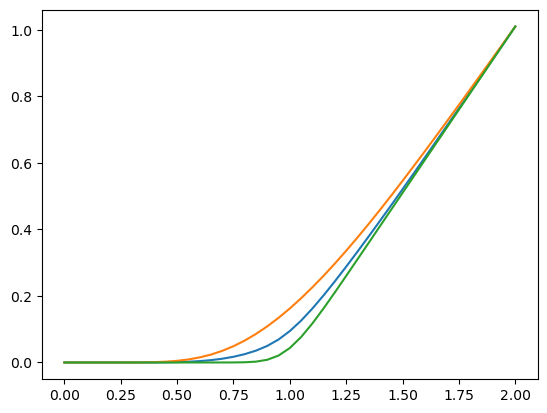

In [44]:
plt.plot(S,V_L)
plt.plot(S,V_H)
plt.plot(S,V)

# Tasks

1. Can you verify the solution converges? What is your best estimate of the option value $V_L(S_0,t=0)$?
2. Can you solve the problem where $H$ switches back to $L$ at the rate $\mu$?